# ML Lab 3 - Linear Regression

## 1. Introduction and Setup

### 1.1 Instructions

* Run all the code cells in chronological order.
* Put your names and student numbers in the indicated cell in the exact indicated format.
* You cannot use additional libraries to the ones imported already for you.
* Your answers must be placed in the indicated answer code cells and must follow the requested format exactly.
* Code cells containing the comment `# STUDENT ANSWER` are answer code cells.
* Do not delete the answer code cells and recreate them as they may have custom metadata used by the automarker. If you accidentally delete one, you must redownload the notebook.
* **Execution Order**: Students must run all prior cells in chronological order. Specific cell dependencies will be highlighted for each task.
* **Determinism Constraint**: Students must not alter any `np.random.seed()` calls. Every call to a random function within this lab is immediately preceded by a seed to ensure identical outputs across multiple executions.

### 1.2 Public Test Cases

The 'public test cases' are used for you to check your answers. Hidden test cases using different dataset values will be used to calculate your mark.

### 1.3 Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set standard seed for the automarker
np.random.seed(42)

## 2. The Auto MPG Dataset and Visual Intuition

In this lab, we will be playing with the classic **Auto MPG** dataset. Our goal is to build a machine learning model that can predict a car's fuel efficiency—measured in Miles Per Gallon (MPG)—based purely on how heavy the car is (`weight`).

From lectures, we know our basic linear model is $y = a + bx + \eta$. Here, $y$ is the MPG, $x$ is the weight, and $\eta$ is the **Gaussian noise**. Physics dictates that heavier cars use more fuel, but two cars that weigh exactly the same might have different aerodynamic shapes or engine efficiencies, resulting in slightly different MPGs. We don't model these extra factors; instead, they manifest as the noise ($\eta$) spread around our trend line.

Let's load the data and look at this noise!

In [6]:
# Provided Code: Load and split the dataset deterministically
df = sns.load_dataset('mpg').dropna()

# Deterministic split into training and testing sets
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

X_train_weight = train_df[['weight']].values
y_train_mpg = train_df['mpg'].values

### Task 1: Baseline Visualisation
Before we do any math, we must understand our data. 

Write `seaborn` code to plot a scatter plot of `weight` (x-axis) vs `mpg` (y-axis) using the training data (`train_df`). Observe the downward trend and the vertical variance (the $\eta$ noise) for cars of similar weights.

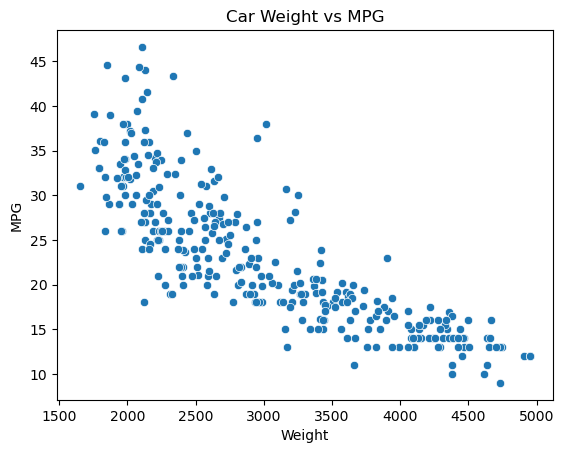

In [7]:
# STUDENT ANSWER
sns.scatterplot(data=train_df, x='weight', y='mpg')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('Car Weight vs MPG')
plt.show()

## 3. Matrix Formulation and Closed-Form Regularisation

We want to learn the optimal parameters $\theta$ for our model. To do this using matrices, we must account for the y-intercept (the bias, $\theta_0$). We achieve this by prepending a column of $1$s to our dataset $X$, creating a "design matrix".

We will also add **regularisation** to prevent overfitting. 

### Task 2: Implement the Closed-Form Solution
Implement `fit_closed_form(X, y, lambda_val)` using the exact closed-form equation derived in lectures: 
$\theta = (X^T X + \lambda I)^{-1} X^T y$. 

**Crucial Rule:** We penalise large weights to keep our curve smooth, but we *do not* penalise the y-intercept. You must ensure the regularisation term does not affect $\theta_0$.

In [8]:
def fit_closed_form(X, y, lambda_val):
    # STUDENT ANSWER
    n = X.shape[0]
    X_design = np.hstack([np.ones((n, 1)), X])
    
    # Build regularisation matrix - do not penalise theta_0
    p = X_design.shape[1]
    reg_matrix = lambda_val * np.eye(p)
    reg_matrix[0, 0] = 0  # Don't regularise the bias term
    
    # Closed-form: theta = (X^T X + lambda I)^-1 X^T y
    theta = np.linalg.inv(X_design.T @ X_design + reg_matrix) @ X_design.T @ y
    
    return theta

**Public Test Case**

In [9]:
# Public Test Case: Task 2
# We test your function on a miniature dataset before unleashing it on the real cars.
X_toy = np.array([[1.0], [2.0], [3.0]])
y_toy = np.array([2.0, 4.0, 5.0])
theta_toy = fit_closed_form(X_toy, y_toy, lambda_val=1)

assert theta_toy.shape == (2,), "Incorrect shape for theta."
# The expected values below are exactly mathematically pre-calculated for X_toy, y_toy, and lambda=1.
assert np.allclose(theta_toy, [1.66666667, 1.0], atol=1e-4), "Theta values are incorrect. Did you remember not to regularise theta_0?"
print("Task 2 Public Test: Passed")

Task 2 Public Test: Passed


## 4. Gradient Descent

The closed-form solution uses a matrix inversion (`np.linalg.inv`), which takes $O(n^3)$ time. For our tiny Auto MPG dataset, this is instant. But if we predicted the MPG for every car type it would likely crash our computer! 

Instead, we can use (batch) **gradient descent**, an iterative approach that accumulates gradients across the dataset and takes small steps of size $\alpha$ (learning rate) down the cost surface.

### Task 3: Implement the Update Rules
Implement the simultaneous update rules for $\theta_0$ (unpenalised) and $\theta_j$ (regularised) exactly as provided in the lecture notes.

In [10]:
def fit_gd(X, y, alpha, epsilon, lambda_val):
    n = X.shape[0]
    X_design = np.hstack([np.ones((n, 1)), X])
    p = X_design.shape[1]
    theta = np.zeros(p)
    
    while True:
        predictions = X_design @ theta
        residuals = predictions - y
        
        # Gradient for theta_0 (no regularisation)
        grad_0 = (1 / n) * np.dot(residuals, X_design[:, 0])
        
        # Gradient for theta_j (with regularisation)
        grad_rest = (1 / n) * (X_design[:, 1:].T @ residuals) + (lambda_val / n) * theta[1:]
        
        # Simultaneous update
        new_theta_0 = theta[0] - alpha * grad_0
        new_theta_rest = theta[1:] - alpha * grad_rest
        
        new_theta = np.concatenate([[new_theta_0], new_theta_rest])
        
        # Check convergence
        if np.linalg.norm(new_theta - theta) < epsilon:
            theta = new_theta
            break
        
        theta = new_theta
    
    return theta

**Public Test Case**

In [11]:
# Public Test Case: Task 3
theta_toy_gd = fit_gd(X_toy, y_toy, alpha=0.01, epsilon=1e-5, lambda_val=1)

assert theta_toy_gd.shape == (2,), "Incorrect shape for theta."
assert np.allclose(theta_toy_gd, theta_toy, atol=1e-2), "Gradient Descent theta should converge closely to the Closed-Form theta."
print("Task 3 Public Test: Passed")

Task 3 Public Test: Passed


## 5. Basis Functions and Model Capacity

Look back at your plot from Task 1. Does the data look like a perfectly straight line? No, it curves. A strict linear model ($y = \theta_0 + \theta_1 x$) will **underfit** this data. 

To increase our model's capacity, we map our inputs to non-linear polynomial basis functions (e.g., $y = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3$). 

### Task 4: Polynomial Expansion
Implement `expand_basis(X, degree)` to map a 1D feature array into a 2D polynomial matrix containing increasing powers of $X$ from 1 up to `degree`.

In [12]:
def expand_basis(X, degree):
    # STUDENT ANSWER
    X_expanded = np.hstack([X ** d for d in range(1, degree + 1)])
    
    return X_expanded

**Public Test Case**

In [13]:
# Public Test Case: Task 4
X_test_basis = np.array([[2], [3]])
X_expanded_test = expand_basis(X_test_basis, degree=3)

assert X_expanded_test.shape == (2, 3), "Output matrix shape is incorrect. Should be (n_samples, degree)."
assert np.allclose(X_expanded_test, [[2, 4, 8], [3, 9, 27]]), "Basis expansion values are incorrect."
print("Task 4 Public Test: Passed")

Task 4 Public Test: Passed


## 6. Visualising the Power of Regularisation

We established earlier that a straight line underfits the Auto MPG data. But if we use too many basis functions (e.g., up to $x^{12}$), our curve will wildly oscillate to try and hit every single noisy data point - this is **overfitting**!

To clearly see this effect, we will isolate a very small subset of our training data (just 14 points) to fit a high-degree polynomial. How do we use a high-capacity model without it overfitting? We use our $\lambda$ penalty to force the parameters to remain small unless they are absolutely necessary.

### The Effect of Dataset Size
You might wonder why we are intentionally shrinking our training data. Overfitting is intrinsically linked to the size of your dataset relative to the capacity of your model. A polynomial of degree 12 has 13 parameters to learn. When the number of training points is close to or less than the number of parameters, the model is under-constrained and will easily contort itself to memorise the random noise in the data. 

Conversely, as the size of a dataset increases, a model has more evidence to find the true underlying pattern, naturally reducing overfitting even without a penalty. By deliberately using a small dataset, we create a worst-case scenario that makes the stabilising effect of regularisation plainly visible.

### A Note on Numerical Instability and Z-Score Normalisation
Car weights are large numbers (e.g., 3500 lbs). If we calculate $3500^{12}$ for our polynomial expansion, the resulting number is so astronomically large that computers cannot store it properly (overflow), causing the matrix inversion in our closed-form solution to crash or return garbage values.

To fix this, we use a technique called **Z-Score Normalisation** (or Standardisation). We shift and scale our input data so that the average weight becomes $0$, and the spread of the data (standard deviation) becomes $1$. 

The formula is: $z = \frac{x - \mu}{\sigma}$

*(Where $\mu$ is the mean and $\sigma$ is the standard deviation). I have provided this scaling code, along with the code to extract the 14-point subset, for you below.*

### Task 5: Fitting and Plotting
1. Expand the small scaled training data (`X_train_small_scaled`) to `degree = 12`.
2. Fit one model with $\lambda = 0$ (no regularisation) and another with $\lambda = 1$ (regularised) using your closed-form function on this **small** dataset.
3. Expand the plotting data (`x_plot_scaled`) to the same degree and compute the predictions for both models.
4. Plot both resulting curves over a scatter plot of the **small** training subset (`X_train_small_raw` against `y_train_small`). 
5. Restrict the y-axis limits (e.g., `plt.ylim(0, 50)`) so that the extreme oscillations of the unregularised model do not compress the rest of the plot. Include a legend to distinguish your models.

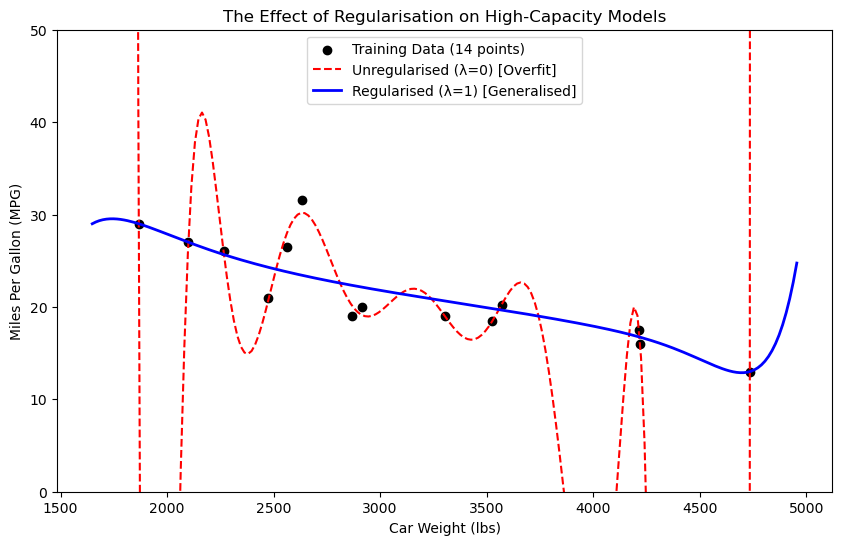

In [14]:
# Set hyperparameters
# Note: I recommend playing around with different values of these hyperparameters to see what happens, but your submission must 
# have degree = 12, lambda_val = 1 and n_datapoints = 14
degree = 12
lambda_val = 1
n_datapoints = 14

# ==========================================
# PROVIDED CODE: Z-Score Normalisation
# ==========================================
X_mean = np.mean(X_train_weight)
X_std = np.std(X_train_weight)
X_train_scaled = (X_train_weight - X_mean) / X_std 

# We also must scale the dummy x-values used for plotting
x_plot_raw = np.linspace(X_train_weight.min(), X_train_weight.max(), 200).reshape(-1, 1)
x_plot_scaled = (x_plot_raw - X_mean) / X_std

# ==========================================
# PROVIDED CODE: Create a small subset
# ==========================================
np.random.seed(42)
# Select random indices from the data
subset_indices = np.random.choice(len(X_train_scaled), size=n_datapoints, replace=False)

# Extract the small subsets for training and plotting
X_train_small_scaled = X_train_scaled[subset_indices]
y_train_small = y_train_mpg[subset_indices]
X_train_small_raw = X_train_weight[subset_indices] # For the scatter plot

# ==========================================
# STUDENT ANSWER
# ==========================================

# 1. Expand the small scaled training data and set to X_poly_train
X_poly_train = expand_basis(X_train_small_scaled, degree)

# 2. Fit both models on the small dataset
theta_unreg = fit_closed_form(X_poly_train, y_train_small, lambda_val=0)
theta_reg = fit_closed_form(X_poly_train, y_train_small, lambda_val=lambda_val)

# 3. Expand the plotting data and compute predictions
x_plot_poly = expand_basis(x_plot_scaled, degree)
n_plot = x_plot_poly.shape[0]
x_plot_design = np.hstack([np.ones((n_plot, 1)), x_plot_poly])

y_plot_unreg = x_plot_design @ theta_unreg
y_plot_reg = x_plot_design @ theta_reg
# 4. Plotting
plt.figure(figsize=(10, 6))

# Plot only the 12 training points used to fit the model
plt.scatter(X_train_small_raw.flatten(), y_train_small, color='black', label='Training Data (14 points)')

# Plot the curves against the raw x-axis for readability
plt.plot(x_plot_raw, y_plot_unreg, label='Unregularised (λ=0) [Overfit]', color='red', linestyle='--')
plt.plot(x_plot_raw, y_plot_reg, label=f'Regularised (λ={lambda_val}) [Generalised]', color='blue', linewidth=2)

# Restrict the y-axis so the extreme oscillations of the unregularised model do not break the scale
plt.ylim(0, 50)
plt.xlabel('Car Weight (lbs)')
plt.ylabel('Miles Per Gallon (MPG)')
plt.title('The Effect of Regularisation on High-Capacity Models')
plt.legend()
plt.show()

## 7. Multiple Choice Questions

### Task 6: MCQ on Regularisation
Based on the lecture notes and the graph you just generated, what is the primary effect of increasing $\lambda$ in regularised linear regression?

A) It increases model capacity to fit noise better.
B) It acts as a force keeping parameters small unless really necessary, making the curve straighter.
C) It penalises the intercept term $\theta_0$.
D) It reduces the training time of Gradient Descent.

Assign your answer as a string to the variable `mcq_answer`.

In [15]:
# STUDENT ANSWER
mcq_answer = 'B'

**Public Test Case**

In [16]:
# Public Test Case: Task 6
assert isinstance(mcq_answer, str), "Answer must be a string."
assert mcq_answer in ['A', 'B', 'C', 'D'], "Answer must be 'A', 'B', 'C', or 'D'."
print("Task 6 Public Test: Passed Format Check")

Task 6 Public Test: Passed Format Check
